In [2]:
from pathlib import Path

import numpy as np
import jax
import ml_confs
import xarray as xr

from spectraformer.input_pipeline import preprocess_dataset, preprocess_dataset_raw

jax.config.update("jax_debug_nans", True)

maindir = Path('/home/dpoteryayev/SpectraFormer/Poisson check.ipynb').parent.resolve()

logdir = maindir / "logs"
ckptdir = maindir / "checkpoints"
# Check if logdir and ckptdir exist, if not create them
logdir.mkdir(parents=True, exist_ok=True)
ckptdir.mkdir(parents=True, exist_ok=True)

datadir = maindir / "data"

model_tag = "min8"  # CHOOSE ONE (.yaml file should exist)
                    # tag also can be found for already trained models in checkpoints folder

configsdir = maindir / "configs"
configsdir.mkdir(parents=True, exist_ok=True)

config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configsdir / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value              ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min8 │ str       │
│ embedding_dim          │ 64                 │ int       │
│ num_heads              │ 8                  │ int       │
│ num_layers             │ 2                  │ int       │
│ learning_rate          │ 0.0001             │ float     │
│ num_epochs             │ 600                │ int       │
│ batch_size             │ 19                 │ int       │
│ dropout_rate           │ 0.5                │ float     │
│ root_rng_seed          │ 0                  │ int       │
│ train_dataset          │ SiC_19x10x3        │ str       │
│ log_every_epochs       │ 5                  │ int       │
│ masked_interval_starts │ [1000, 2500]       │ list[int] │
│ masked_interval_ends   │ [1700, 2900]       │ list[int] │
└────────────────────────┴────────────────────┴───────────┘

In [3]:
# Load the full dataset
full_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
)
full_ds

Dropped 0 spectra


<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[0.06321972, 0.06322556, 0.07688599, ..., 0.06697275, 0.07813979,
        0.08525848],
       [0.07789186, 0.06324255, 0.08054267, ..., 0.05904082, 0.07665442,
        0.07776609],
       [0.07257985, 0.06325956, 0.07146665, ..., 0.06568322, 0.07817971,
        0.07402785],
       ...,
       [0.02190699, 0.01672867, 0.01595614, ..., 0.02191288, 0.01717111,
        0.01904489],
       [0.01359051, 0.02230961, 0.0182329 , ..., 0.02026475, 0.02093749,
        0.01670395],
       [0.01026167, 0.0111595 , 0.02050487, ..., 0.01364431, 0.01529626,
        0.03782147]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

In [19]:
print(np.any(np.isnan(full_ds)))
print(np.any(np.isinf(full_ds)))

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4
<xarray.DataArray ()>
array(False)


In [41]:
np.isnan(full_ds).sum().item()

0

In [32]:
import jax.numpy as jnp

In [48]:
jnp.isnan(jnp.array(full_ds)).sum().item()

0

In [49]:
jnp.any(jnp.isnan(jnp.array(full_ds)))

Array(False, dtype=bool)

In [12]:
np.shape(full_ds)


(1015, 570)

In [5]:
# mean_values = np.mean(full_ds, axis=1)
# variance_values = np.var(full_ds, axis=1)
# std_values = np.std(full_ds, axis=1)

mean_values = full_ds.mean(
    dim=['spectra']
)

variance_values = full_ds.var(
    dim=['spectra']
)

std_values = full_ds.std(
    dim=['spectra']
)

print("Mean values:", mean_values)
print("Variance values:", variance_values)

Mean values: <xarray.DataArray (wave_number: 1015)>
array([0.0717117 , 0.07501796, 0.07638922, ..., 0.01903325, 0.01903031,
       0.01903139])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Variance values: <xarray.DataArray (wave_number: 1015)>
array([9.11590489e-05, 9.24154280e-05, 8.85681243e-05, ...,
       7.04859414e-05, 7.08718476e-05, 6.69142741e-05])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


In [ ]:
import matplotlib.pyplot as plt

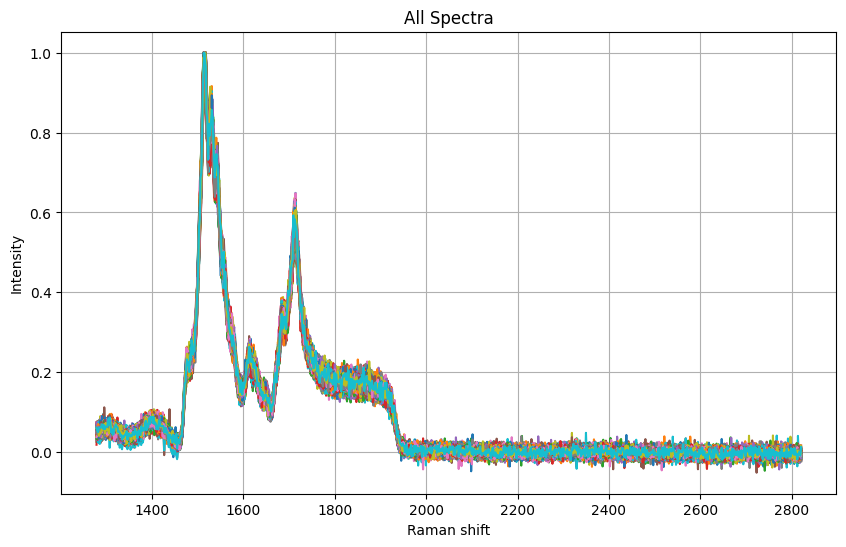

In [ ]:
# Stack the spatial dimensions ("X_0", "X_1", "X_2") into a single dimension called "spectra".
stacked_ds = full_ds.stack(spectra=("X_0", "X_1", "X_2"))

fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(stacked_ds.spectra.size):
    ax.plot(stacked_ds["wave_number"], stacked_ds.isel(spectra=i), alpha=1)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra')

ax.grid(visible=True, which='both', axis='both')

plt.show()

In [ ]:
bg_removal_window = (2200, 2500)
bg_removal_window = full_ds.sel(wave_number=slice(*bg_removal_window))
bg_values = bg_removal_window.median(dim="wave_number")
full_ds_bg_removed_per_spectra = full_ds - bg_values

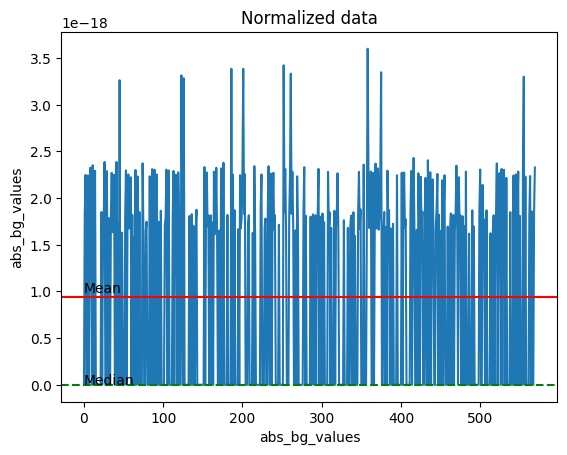

In [ ]:
fig, ax = plt.subplots()
# ax.scatter(
#     x=abs(bg_values), 
#     y=abs(bg_values)
#     )
stacked_bg_values = bg_values.stack(spectra=("X_0", "X_1", "X_2"))
ax.plot(abs(stacked_bg_values))
ax.set_xlabel('abs_bg_values')
ax.set_ylabel('abs_bg_values')
ax.set_title('Normalized data')

ax.axhline(y=abs(bg_values).mean(), color='r', linestyle='-')
ax.annotate('Mean', (1e-18, 1.05*abs(bg_values).mean()))

ax.axhline(y=abs(bg_values).median(), color='g', linestyle='--')
ax.annotate('Median', (1e-18, 1.05*abs(bg_values).median()))

# ax.set_yscale('log')
# ax.set_xscale('log')

plt.show()

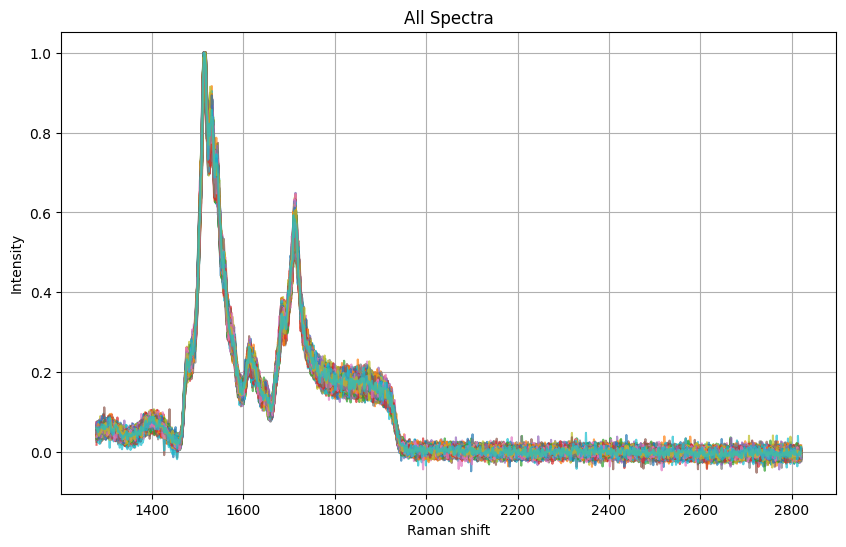

In [ ]:
# Stack the spatial dimensions ("X_0", "X_1", "X_2") into a single dimension called "spectra".
stacked_ds_bg_removed_per_spectra = full_ds_bg_removed_per_spectra.stack(spectra=("X_0", "X_1", "X_2"))

fig, ax = plt.subplots(figsize=(10, 6))
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(stacked_ds_bg_removed_per_spectra.spectra.size):
    ax.plot(stacked_ds_bg_removed_per_spectra["wave_number"], stacked_ds_bg_removed_per_spectra.isel(spectra=i), alpha=0.7)

ax.set_xlabel('Raman shift')
ax.set_ylabel('Intensity')
ax.set_title('All Spectra')

ax.grid(visible=True, which='both', axis='both')

plt.show()

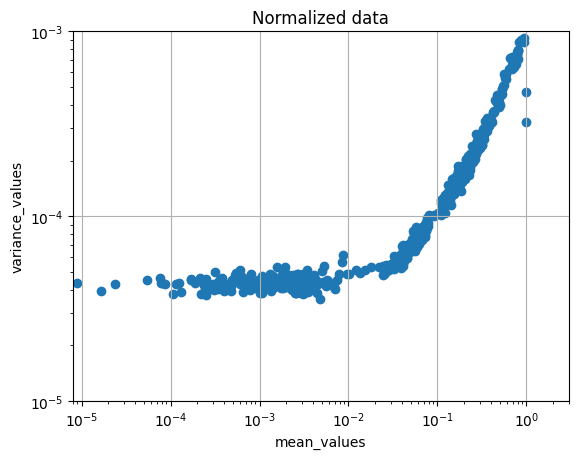

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=mean_values, y=variance_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('variance_values')
ax.set_title('Normalized data')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim([8e-6,3e0])
ax.set_ylim([1e-5,1e-3])

ax.grid(visible=True, which='major', axis='both')

plt.show()

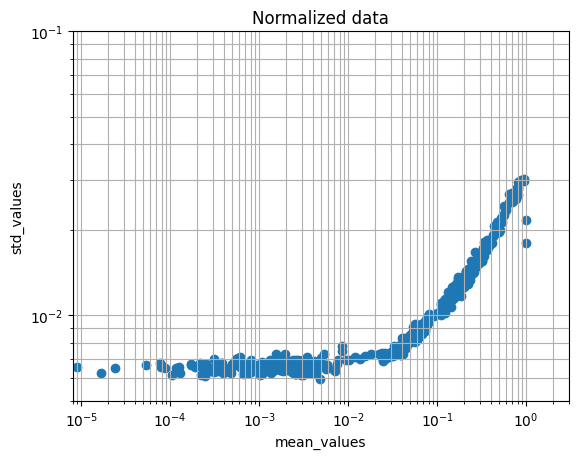

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=mean_values, y=std_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('std_values')
ax.set_title('Normalized data')
# ax.set_ylim([0,0.14])


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim([8e-6,3e0])
ax.set_ylim([5e-3,1e-1])

ax.grid(visible=True, which='both', axis='both')

plt.show()

/home/dpoteryayev/.conda/envs/spectraformer/lib/python3.11/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)


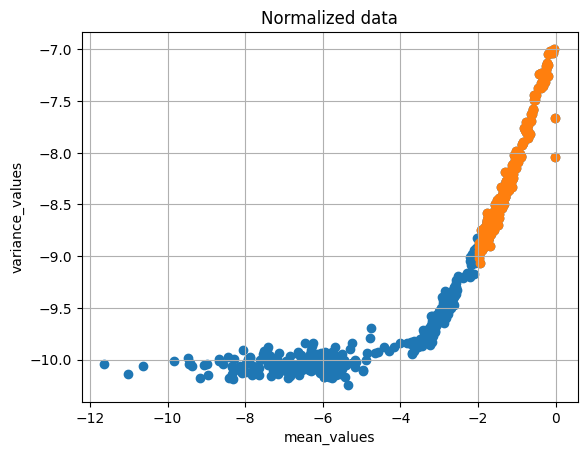

array([ 0.9706846 , -7.06067636])

In [ ]:
log_mean = np.log(mean_values)
log_var = np.log(variance_values)

linear_log_mean = log_mean[log_mean>-2]
linear_log_var = log_var[log_mean>-2]

coef1 = np.polyfit(linear_log_mean,linear_log_var,1)
poly1d_fn = np.poly1d(coef1)

fig, ax = plt.subplots()

ax.scatter(x=log_mean, y=log_var)
ax.scatter(x=linear_log_mean, y=linear_log_var)

ax.set_xlabel('mean_values')
ax.set_ylabel('variance_values')
ax.set_title('Normalized data')
# ax.set_ylim([0,0.14])


# ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_xlim([-12,0.5])
# ax.set_ylim([-6,-3])

ax.grid(visible=True, which='both', axis='both')

plt.show()
coef1

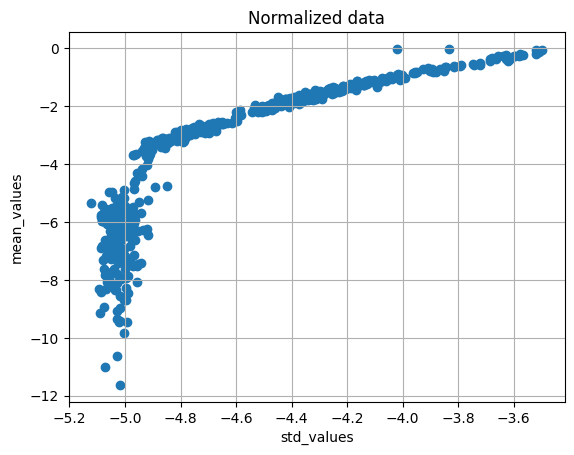

array([ 0.4853423 , -3.53033818])

In [ ]:
log_mean = np.log(mean_values)
log_std = np.log(std_values)

linear_log_mean = log_mean[log_mean>-2]
linear_log_std = log_std[log_mean>-2]

coef = np.polyfit(linear_log_mean,linear_log_std,1)
poly1d_fn = np.poly1d(coef)

fig, ax = plt.subplots()

ax.scatter(x=log_std, y=log_mean)
# ax.scatter(x=linear_log_mean, y=linear_log_std)

ax.set_xlabel('std_values')
ax.set_ylabel('mean_values')
ax.set_title('Normalized data')
# ax.set_ylim([0,0.14])


# ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_xlim([-12,0.5])
# ax.set_ylim([-6,-3])

ax.grid(visible=True, which='both', axis='both')

plt.show()
coef

In [ ]:
raw_ds = preprocess_dataset_raw(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc"), raw = True
)
raw_ds

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[69.776327, 62.500558, 62.167508, ..., 74.334424, 76.337606,
        66.750705],
       [85.970137, 62.517358, 65.124181, ..., 65.530613, 74.886495,
        60.884754],
       [80.107214, 62.534173, 57.785608, ..., 72.903149, 76.376607,
        57.958   ],
       ...,
       [24.179001, 16.536847, 12.901614, ..., 24.321549, 16.775088,
        14.910659],
       [15.      , 22.053784, 14.74253 , ..., 22.49226 , 20.454597,
        13.077882],
       [11.32592 , 11.031539, 16.57957 , ..., 15.144097, 14.943475,
        29.611247]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

In [ ]:
raw_mean_values = np.mean(raw_ds, axis=1)
raw_variance_values = np.var(raw_ds, axis=1)
raw_std_values = np.std(raw_ds, axis=1)

print("Raw Mean values:", mean_values)
print("Raw Variance values:", variance_values)

Raw Mean values: <xarray.DataArray (wave_number: 1015)>
array([ 0.04992656,  0.05331041,  0.05471408, ..., -0.00398831,
       -0.00398997, -0.00399094])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Raw Variance values: <xarray.DataArray (wave_number: 1015)>
array([6.88394660e-05, 7.01833326e-05, 6.59199169e-05, ...,
       4.43188214e-05, 4.20103104e-05, 4.19862893e-05])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


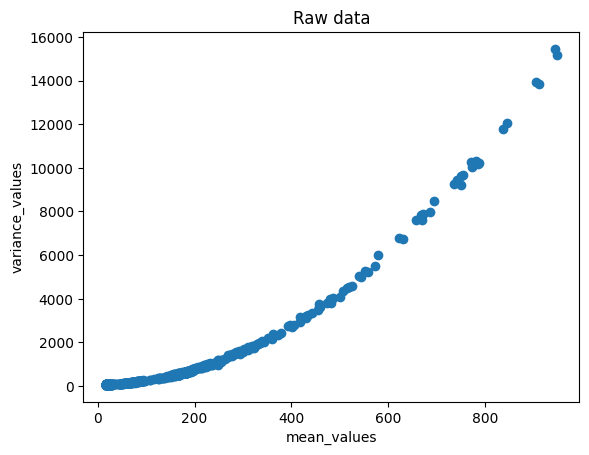

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_variance_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('variance_values')
ax.set_title('Raw data')
plt.show()

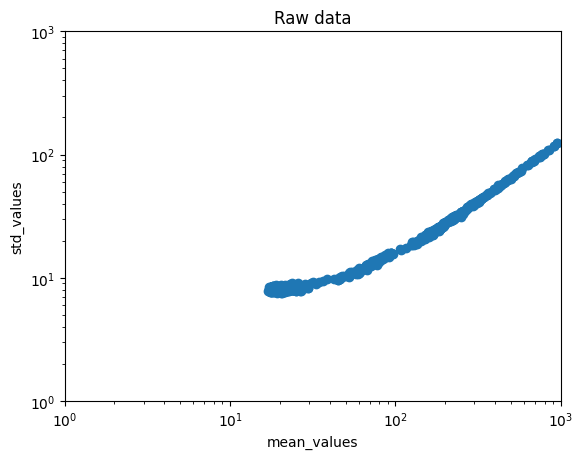

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_std_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('std_values')
ax.set_title('Raw data')
ax.set_ylim([1e0,1e3])
ax.set_xlim([1e0,1e3])
ax.set_yscale('log')
ax.set_xscale('log')
plt.show()

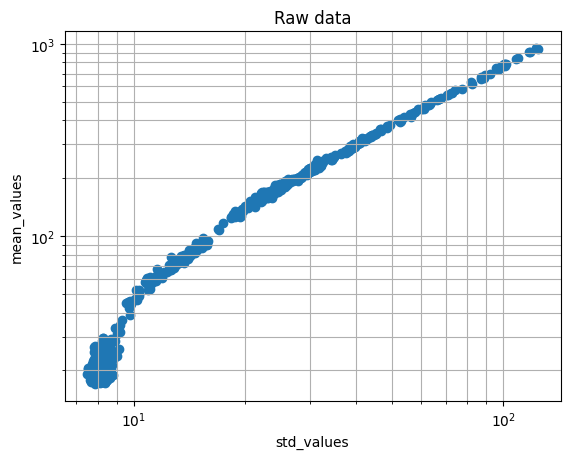

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_std_values, y=raw_mean_values)
ax.set_xlabel('std_values')
ax.set_ylabel('mean_values')
ax.set_title('Raw data')
# ax.set_ylim([1e0,1e4])
# ax.set_xlim([1e0,1e3])
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(visible=True, which='both', axis='both')
plt.show()

In [ ]:
# Shape parameter alpha = mean**2 / std**2
raw_param_alpha_values = raw_mean_values**2/raw_std_values**2
print(raw_param_alpha_values)
print(raw_param_alpha_values.mean())
print(raw_param_alpha_values.median())

<xarray.DataArray (wave_number: 1015)>
array([28.58498329, 29.4102909 , 30.72574913, ...,  4.78182347,
        4.92155847,  5.29117432])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
<xarray.DataArray ()>
array(23.04142686)
<xarray.DataArray ()>
array(8.46656901)


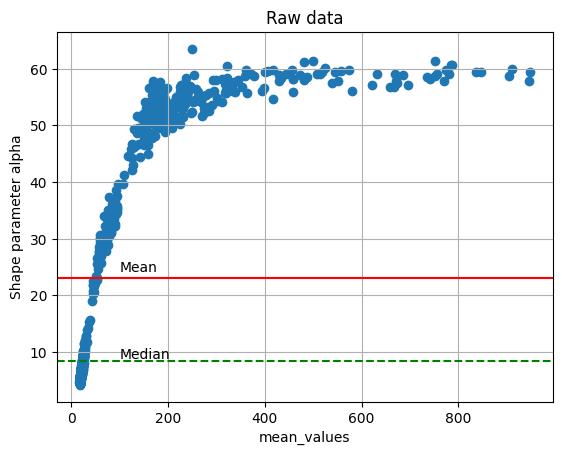

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_param_alpha_values)

ax.set_xlabel('mean_values')
ax.set_ylabel('Shape parameter alpha')
ax.set_title('Raw data')

# ax.set_xlim([-20, 20])
# ax.set_ylim([-20, 20])

ax.axhline(y=raw_param_alpha_values.mean(), color='r', linestyle='-')
ax.annotate('Mean', (100,1.05*raw_param_alpha_values.mean()))

ax.axhline(y=raw_param_alpha_values.median(), color='g', linestyle='--')
ax.annotate('Median', (100,1.05*raw_param_alpha_values.median()))

# ax.set_yscale('log')
# ax.set_xscale('log')

ax.grid(visible=True, which='both', axis='both')
plt.show()

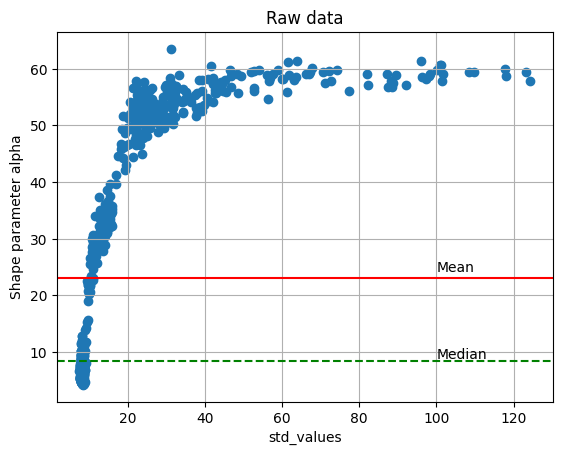

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_std_values, y=raw_param_alpha_values)

ax.set_xlabel('std_values')
ax.set_ylabel('Shape parameter alpha')
ax.set_title('Raw data')

# ax.set_xlim([-20, 20])
# ax.set_ylim([-20, 20])

ax.axhline(y=raw_param_alpha_values.mean(), color='r', linestyle='-')
ax.annotate('Mean', ( 100, 1.05*raw_param_alpha_values.mean()))

ax.axhline(y=raw_param_alpha_values.median(), color='g', linestyle='--')
ax.annotate('Median', ( 100, 1.05*raw_param_alpha_values.median()))

# ax.set_yscale('log')
# ax.set_xscale('log')
ax.grid(visible=True, which='both', axis='both')
plt.show()

In [ ]:
raw_ds_1 = xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
raw_ds_1

<xarray.DataArray (X_0: 19, X_1: 10, X_2: 3, wave_number: 1015)>
array([[[[ 74.983772,  91.177582,  85.314659, ...,  29.386446,
           20.207445,  16.533365],
         [ 73.513504,  73.530304,  73.547119, ...,  27.549793,
           33.06673 ,  22.044485],
         [ 67.632423,  70.589096,  63.250523, ...,  18.366529,
           20.207445,  22.044485]],

        [[ 92.627014,  80.883339,  85.314659, ...,  20.203182,
           31.229689,  25.718567],
         [ 76.454041,  98.530609,  79.430893, ...,  27.549793,
           29.392649,  36.74081 ],
         [ 58.810799,  69.118492,  57.366753, ...,  25.71314 ,
           20.207445,  23.881527]],

        [[ 82.335121,  98.530609,  88.256546, ...,  36.733059,
           25.718567,  18.370405],
         [ 77.924309,  73.530304,  83.843719, ...,  27.549793,
           34.90377 ,  25.718567],
         [ 54.39999 ,  70.589096,  58.837696, ...,  22.039835,
           23.881527,  23.881527]],
...
        [[ 74.983772,  98.530609, 107.378799, ...,  31.223101,
           31.229689,  33.06673 ],
         [ 61.751339,  83.824547,  80.901833, ...,  27.549793,
           18.370405,  25.718567],
         [ 61.751339,  73.530304,  70.605232, ...,  23.876488,
           20.207445,  23.881527]],

        [[ 80.864853,  73.530304,  98.553139, ...,  20.203182,
           23.881527,  22.044485],
         [ 82.335121,  83.824547,  86.785599, ...,  25.71314 ,
           38.57785 ,  29.392649],
         [ 54.39999 ,  58.824245,  63.250523, ...,  25.71314 ,
           16.533365,  20.207445]],

        [[ 86.745934,  77.942123,  85.314659, ...,  36.733059,
           34.90377 ,  27.555607],
         [ 85.275658,  83.824547,  85.314659, ...,  25.71314 ,
           29.392649,  23.881527],
         [ 72.043228,  66.177277,  63.250523, ...,  20.203182,
           18.370405,  34.90377 ]]]])
Coordinates:
  * X_0          (X_0) int64 0 1 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * X_1          (X_1) int64 0 1 2 3 4 5 6 7 8 9
  * X_2          (X_2) int64 0 2 4
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Attributes:
    system_type:  SiC

In [ ]:
raw_1_max_values = np.max(raw_ds_1, axis=3)
raw_1_max_values

<xarray.DataArray (X_0: 19, X_1: 10, X_2: 3)>
array([[[1108.918945,  999.546082,  814.032349],
        [1077.018555, 1032.965576,  815.739014],
        [1089.171021, 1036.003662,  789.732849],
        [1095.247314,  969.164734,  780.620544],
        [1099.804565, 1025.370239,  800.363892],
        [1093.728271, 1011.465515,  779.101807],
        [1102.588501,  984.355408,  803.586487],
        [1104.361694,  988.912659,  798.845154],
        [1081.575684, 1019.294006,  768.825073],
        [1102.588501,  960.050354,  800.54834 ]],

       [[1078.537598, 1022.096558,  814.21991 ],
        [1099.551147, 1001.065186,  806.438721],
        [1118.033325, 1013.217712,  815.363098],
        [1105.625977, 1000.834534,  769.989502],
        [1122.331909, 1058.545776,  788.214111],
        [1120.81311 ,  996.507996,  802.067383],
        [1121.071411,  991.950745,  809.476196],
        [1072.461304, 1010.179565,  799.029236],
        [1067.904175, 1005.390686,  812.700867],
...
        [1127.147705,  973.721985,  815.551025],
        [1086.132935, 1006.909363,  764.090698],
        [1110.182129, 1016.021667,  776.064392],
        [1064.865967, 1017.540405,  809.476196],
        [1073.73291 , 1019.294006,  792.770264],
        [1111.700806, 1012.984253,  797.326416],
        [1099.551147, 1011.698669,  826.182068],
        [1095.247314,  997.797058,  783.657959],
        [1093.476196,  988.912659,  832.256897]],

       [[1111.700806,  998.027039,  818.588501],
        [1122.331909, 1019.059143,  814.21991 ],
        [1124.109619,  999.315796,  803.401306],
        [1104.1073  , 1008.428101,  792.953003],
        [1090.690186,  994.759644,  770.166992],
        [1108.918945,  988.684753,  821.625916],
        [1122.590576,  990.203491,  792.587646],
        [1127.147705, 1010.179565,  818.588501],
        [1090.438843,  985.647339,  800.363892],
        [1122.331909,  985.874512,  788.214111]]])
Coordinates:
  * X_0      (X_0) int64 0 1 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * X_1      (X_1) int64 0 1 2 3 4 5 6 7 8 9
  * X_2      (X_2) int64 0 2 4

(array([401357.,  91716.,  44902.,  15581.,   8806.,   6055.,   4717.,
          3423.,   1437.,    556.]),
 array([ -21.722507 ,   95.7203614,  213.1632298,  330.6060982,
         448.0489666,  565.491835 ,  682.9347034,  800.3775718,
         917.8204402, 1035.2633086, 1152.706177 ]),
 <BarContainer object of 10 artists>)

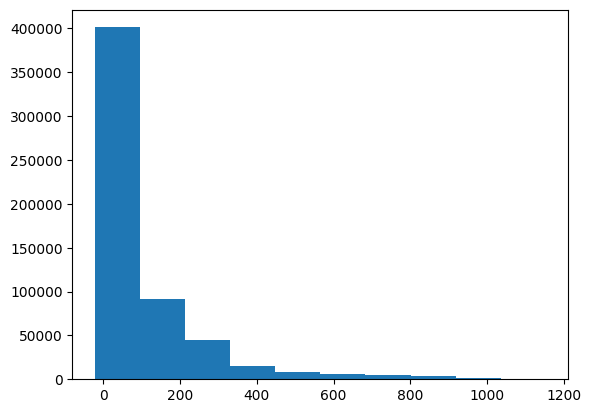

In [ ]:
raw_ds_1.plot.hist()

(array([ 5.,  7.,  9., 16., 29., 37., 33., 32., 12.,  6.,  1.,  2.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         4., 11., 19., 24., 20., 38., 32., 18., 10.,  6.,  5., 11.,  8.,
        11., 23., 31., 25., 29., 18., 14., 11.,  6.,  3.,  2.]),
 array([ 756.321045  ,  764.24874764,  772.17645028,  780.10415292,
         788.03185556,  795.9595582 ,  803.88726084,  811.81496348,
         819.74266612,  827.67036876,  835.5980714 ,  843.52577404,
         851.45347668,  859.38117932,  867.30888196,  875.2365846 ,
         883.16428724,  891.09198988,  899.01969252,  906.94739516,
         914.8750978 ,  922.80280044,  930.73050308,  938.65820572,
         946.58590836,  954.513611  ,  962.44131364,  970.36901628,
         978.29671892,  986.22442156,  994.1521242 , 1002.07982684,
        1010.00752948, 1017.93523212, 1025.86293476, 1033.7906374 ,
        1041.71834004, 1049.64604268, 1057.57374532, 1065.50144796,
        1073.4291506 , 1081.35685324

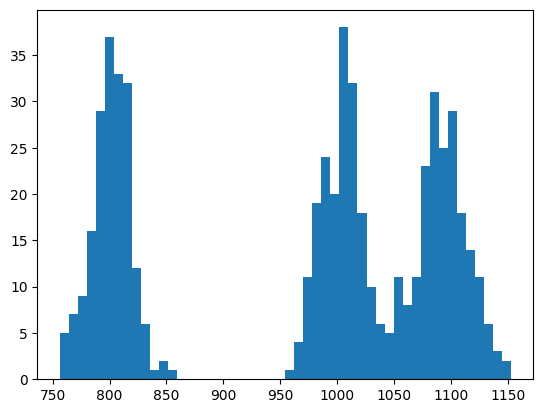

In [ ]:
raw_1_max_values.plot.hist(bins=50)

(array([ 1.,  0.,  1.,  0.,  0., 11.,  0.,  0.,  5.,  0.,  0., 13.,  0.,
        15.,  0.,  0., 20.,  0.,  0., 14.,  0.,  0., 21.,  0.,  0., 18.,
         0., 28.,  0.,  0., 13.,  0.,  0.,  8.,  0.,  0.,  9.,  0.,  7.,
         0.,  0.,  3.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  1.]),
 array([15.15258   , 15.75868322, 16.36478644, 16.97088966, 17.57699288,
        18.1830961 , 18.78919932, 19.39530254, 20.00140576, 20.60750898,
        21.2136122 , 21.81971542, 22.42581864, 23.03192186, 23.63802508,
        24.2441283 , 24.85023152, 25.45633474, 26.06243796, 26.66854118,
        27.2746444 , 27.88074762, 28.48685084, 29.09295406, 29.69905728,
        30.3051605 , 30.91126372, 31.51736694, 32.12347016, 32.72957338,
        33.3356766 , 33.94177982, 34.54788304, 35.15398626, 35.76008948,
        36.3661927 , 36.97229592, 37.57839914, 38.18450236, 38.79060558,
        39.3967088 , 40.00281202, 40.60891524, 41.21501846, 41.82112168,
        42.4272249 , 43.03332812, 43.63943134, 44.24553456,

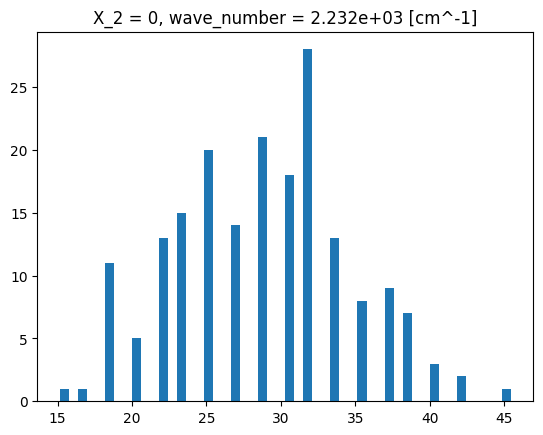

In [ ]:
# raw_ds_1[:,:,0,161].plot.hist(bins=50)
raw_ds_1[:,:,0,600].plot.hist(bins=50)

In [ ]:
# Properly normalized data
prop_norm_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc"),
    option = 'proper_bg_proper_norm'
)
prop_norm_ds

<xarray.DataArray (X_0: 19, X_1: 10, X_2: 3, wave_number: 1015)>
array([[[[0.06321972, 0.07789186, 0.07257985, ..., 0.02190699,
          0.01359051, 0.01026167],
         [0.06322556, 0.06324255, 0.06325956, ..., 0.01672867,
          0.02230961, 0.0111595 ],
         [0.07688599, 0.08054267, 0.07146665, ..., 0.01595614,
          0.0182329 , 0.02050487]],

        [[0.0875426 , 0.07665709, 0.08076459, ..., 0.02041111,
          0.03063186, 0.02552346],
         [0.06919886, 0.09068203, 0.0720957 , ..., 0.02160913,
          0.02340245, 0.0305531 ],
         [0.06790227, 0.08059538, 0.06612404, ..., 0.0271451 ,
          0.02036526, 0.02488961]],

        [[0.07404954, 0.08894395, 0.07949526, ..., 0.03211098,
          0.02198135, 0.01522352],
         [0.0686143 , 0.06434272, 0.07436879, ..., 0.0196433 ,
          0.02679238, 0.0178631 ],
         [0.06297521, 0.08360477, 0.06863012, ..., 0.0217391 ,
          0.02408594, 0.02408594]],
...
        [[0.05758179, 0.07867258, 0.08659786, ..., 0.01838556,
          0.01839146, 0.02003689],
         [0.05435078, 0.07635931, 0.07344516, ..., 0.02024945,
          0.01109696, 0.01842359],
         [0.06948812, 0.08397005, 0.08037375, ..., 0.02292196,
          0.01841097, 0.02292816]],

        [[0.06480595, 0.05801177, 0.08119105, ..., 0.0086135 ,
          0.01202084, 0.01031914],
         [0.07495164, 0.0764769 , 0.0795092 , ..., 0.01696718,
          0.03014145, 0.02073522],
         [0.07734304, 0.08281525, 0.08828996, ..., 0.04186127,
          0.03050712, 0.03505147]],

        [[0.06697275, 0.05904082, 0.06568322, ..., 0.02191288,
          0.02026475, 0.01364431],
         [0.07813979, 0.07665442, 0.07817971, ..., 0.01717111,
          0.02093749, 0.01529626],
         [0.08525848, 0.07776609, 0.07402785, ..., 0.01904489,
          0.01670395, 0.03782147]]]])
Coordinates:
  * X_0          (X_0) int64 0 1 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * X_1          (X_1) int64 0 1 2 3 4 5 6 7 8 9
  * X_2          (X_2) int64 0 2 4
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03

In [ ]:
prop_norm_mean_values = prop_norm_ds.mean(
    dim=['X_0', 'X_1', 'X_2']
)

prop_norm_variance_values = prop_norm_ds.var(
    dim=['X_0', 'X_1', 'X_2']
)

prop_norm_std_values = prop_norm_ds.std(
    dim=['X_0', 'X_1', 'X_2']
)

print("Mean values:", mean_values)
print("Variance values:", variance_values)

Mean values: <xarray.DataArray (wave_number: 1015)>
array([ 0.04992656,  0.05331041,  0.05471408, ..., -0.00398831,
       -0.00398997, -0.00399094])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Variance values: <xarray.DataArray (wave_number: 1015)>
array([6.88394660e-05, 7.01833326e-05, 6.59199169e-05, ...,
       4.43188214e-05, 4.20103104e-05, 4.19862893e-05])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


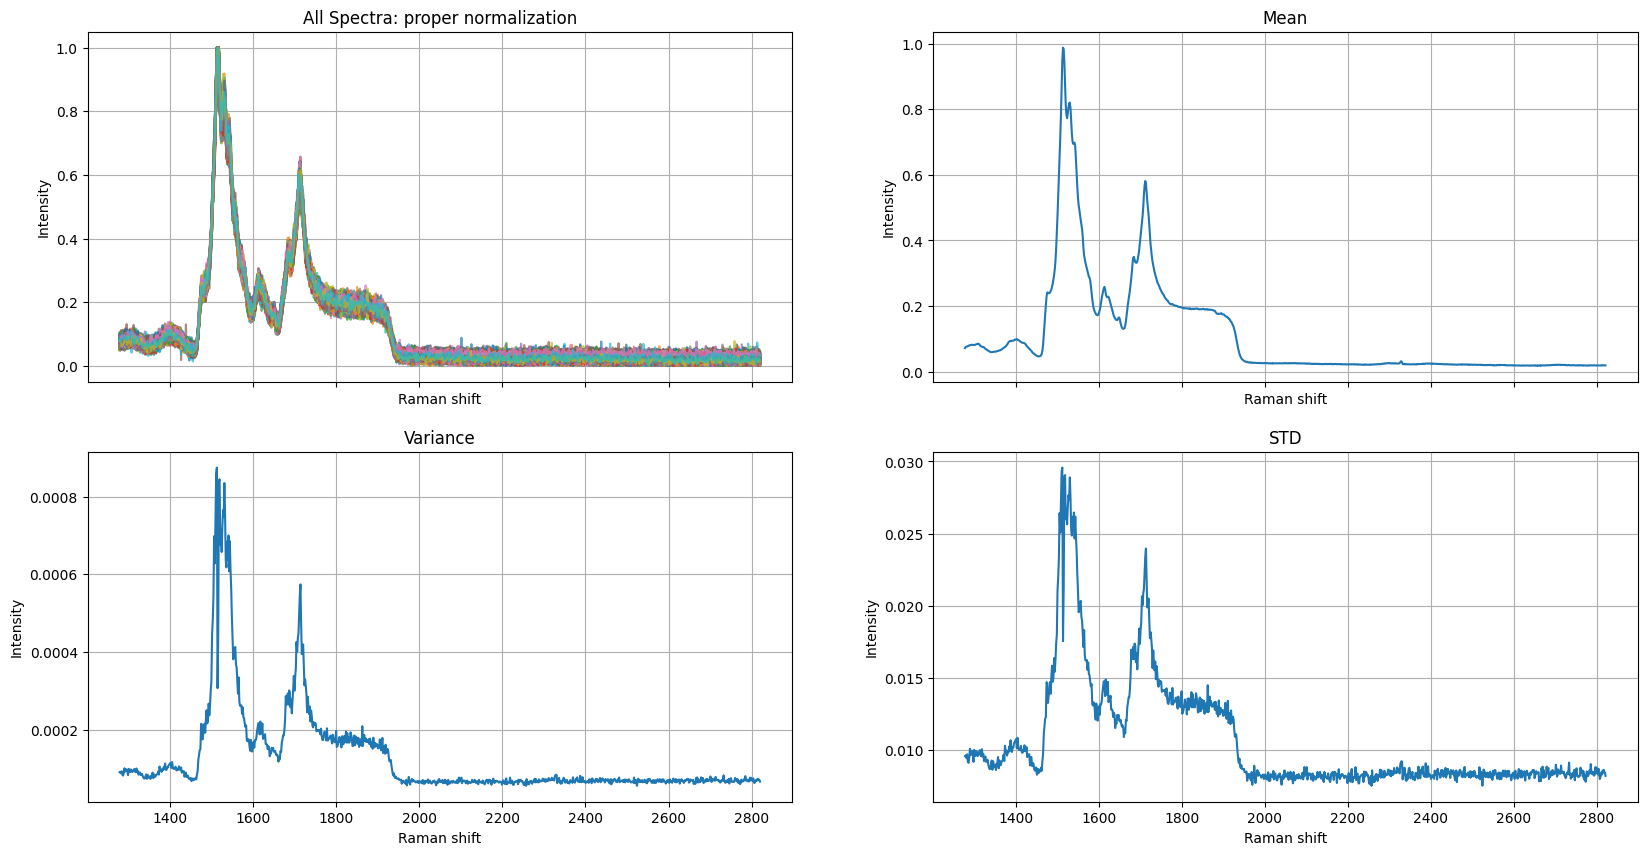

In [ ]:
# Stack the spatial dimensions ("X_0", "X_1", "X_2") into a single dimension called "spectra".
stacked_prop_norm_ds = prop_norm_ds.stack(spectra=("X_0", "X_1", "X_2"))

fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(stacked_prop_norm_ds.spectra.size):
    axes[0,0].plot(stacked_prop_norm_ds["wave_number"], stacked_prop_norm_ds.isel(spectra=i), alpha=0.7)

axes[0,0].set_xlabel('Raman shift')
axes[0,0].set_ylabel('Intensity')
axes[0,0].set_title('All Spectra: proper normalization')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].plot(prop_norm_mean_values["wave_number"], prop_norm_mean_values)
axes[0,1].set_xlabel('Raman shift')
axes[0,1].set_ylabel('Intensity')
axes[0,1].set_title('Mean')
axes[0,1].grid(visible=True, which='both', axis='both')

axes[1,0].plot(prop_norm_variance_values["wave_number"], prop_norm_variance_values)
axes[1,0].set_xlabel('Raman shift')
axes[1,0].set_ylabel('Intensity')
axes[1,0].set_title('Variance')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].plot(prop_norm_std_values["wave_number"], prop_norm_std_values)
axes[1,1].set_xlabel('Raman shift')
axes[1,1].set_ylabel('Intensity')
axes[1,1].set_title('STD')
axes[1,1].grid(visible=True, which='both', axis='both')

plt.show()

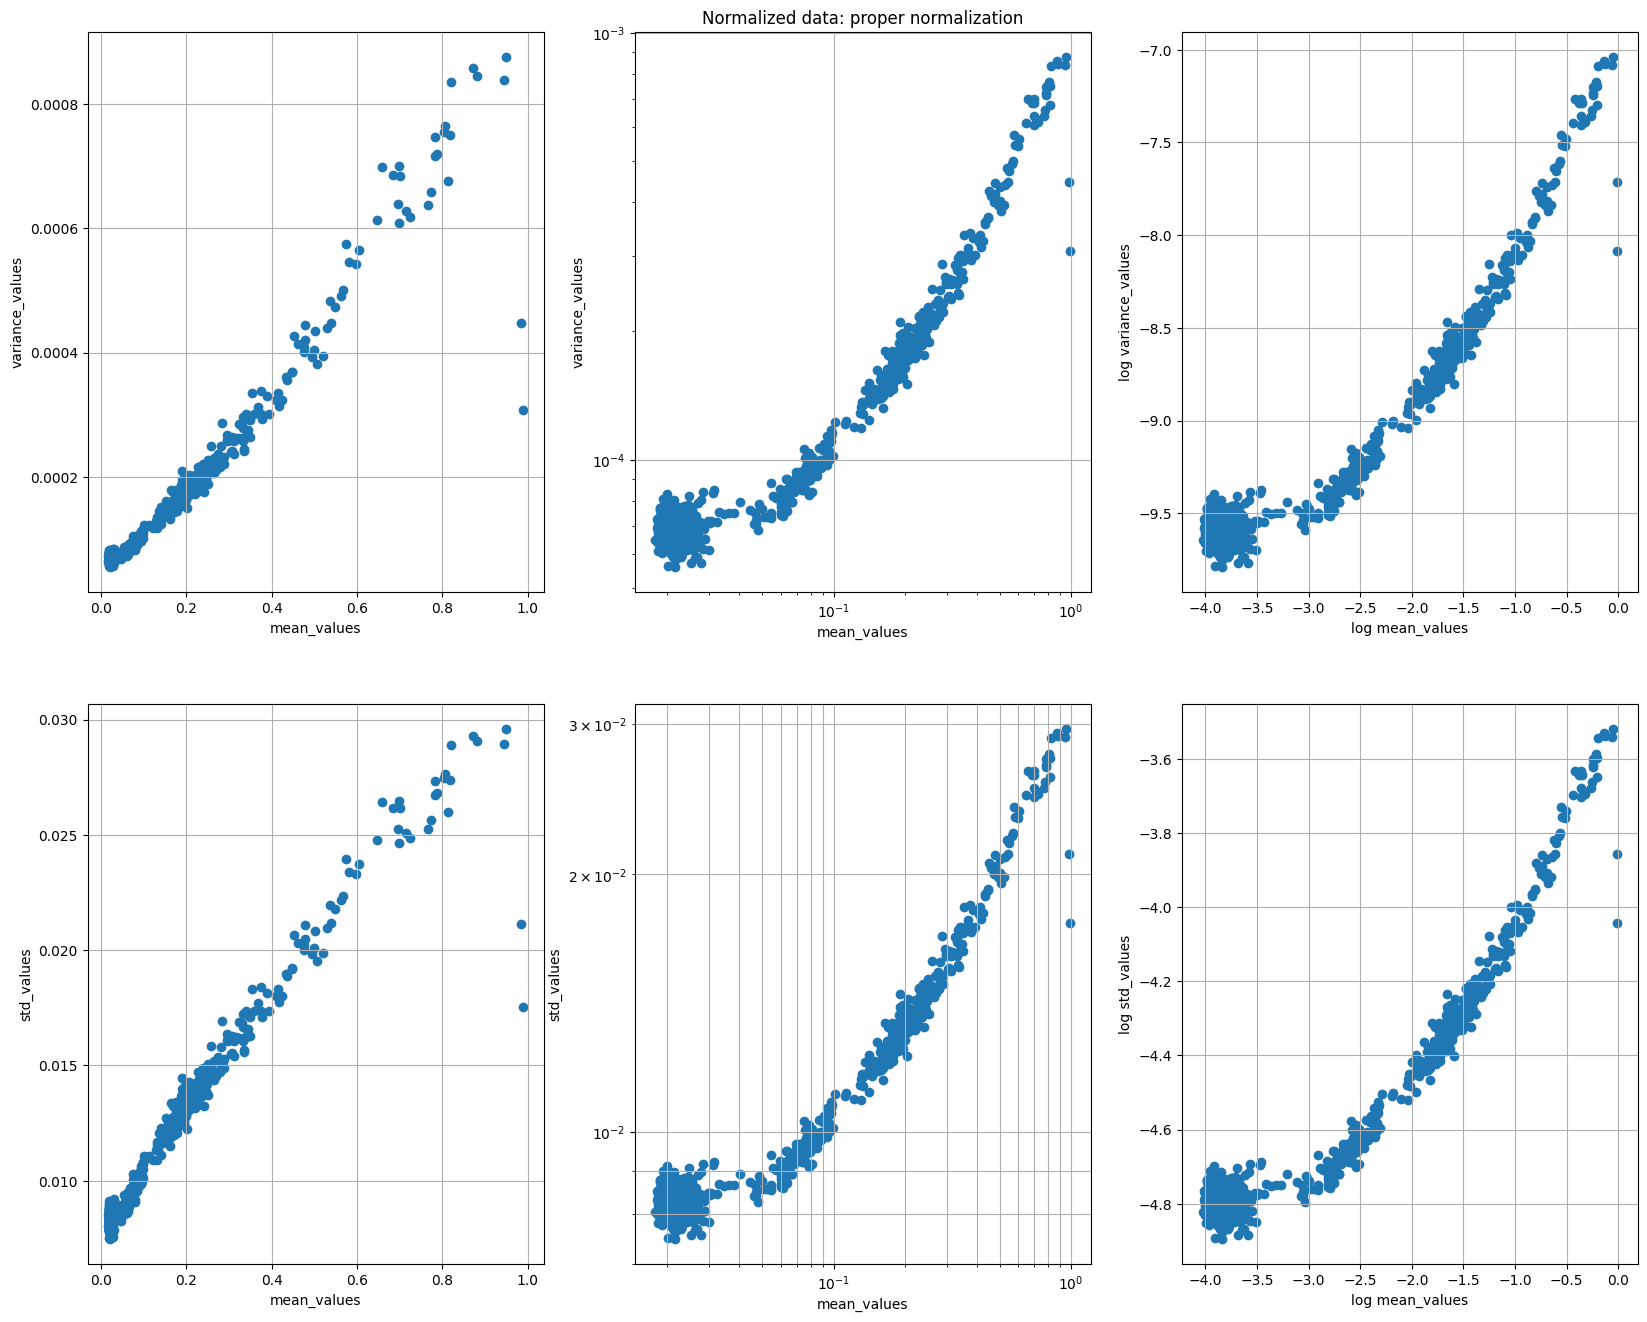

In [ ]:
fig = plt.figure(figsize=(20,16))
axes = fig.subplots(2, 3)

axes[0,0].scatter(x=prop_norm_mean_values, y=prop_norm_variance_values)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].grid(visible=True, which='major', axis='both')


axes[0,1].scatter(x=prop_norm_mean_values, y=prop_norm_variance_values)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('variance_values')
axes[0,1].set_title('Normalized data: proper normalization')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
axes[0,1].grid(visible=True, which='major', axis='both')

axes[0,2].scatter(x=np.log(prop_norm_mean_values), y=np.log(prop_norm_variance_values))
axes[0,2].set_xlabel('log mean_values')
axes[0,2].set_ylabel('log variance_values')
axes[0,2].grid(visible=True, which='both', axis='both')

axes[1,0].scatter(x=prop_norm_mean_values, y=prop_norm_std_values)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('std_values')
axes[1,0].grid(visible=True, which='major', axis='both')

axes[1,1].scatter(x=prop_norm_mean_values, y=prop_norm_std_values)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('std_values')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
axes[1,1].grid(visible=True, which='both', axis='both')

axes[1,2].scatter(x=np.log(prop_norm_mean_values), y=np.log(prop_norm_std_values))
axes[1,2].set_xlabel('log mean_values')
axes[1,2].set_ylabel('log std_values')
axes[1,2].grid(visible=True, which='both', axis='both')

plt.show()

In [ ]:
# Choosing a linear part
linear_prop_norm_mean_values = prop_norm_mean_values[prop_norm_mean_values>1e-1]
linear_prop_norm_variance_values = prop_norm_variance_values[prop_norm_mean_values>1e-1]
linear_prop_norm_std_values = prop_norm_std_values[prop_norm_mean_values>1e-1]

# Fitting with 1-order polynom
variance_vs_mean_fit = np.polyfit(
    linear_prop_norm_mean_values,
    linear_prop_norm_variance_values,
    1
)
std_vs_mean_fit = np.polyfit(
    linear_prop_norm_mean_values,
    linear_prop_norm_std_values,
    1
)
# Results: [slope, intersect]
print('Normalized dataset')
print(f"Variance as a function of mean: {variance_vs_mean_fit}")
print(f"STD as a function of mean: {std_vs_mean_fit}")

############################################################## LOG part ##############################################################
# Choosing a linear part
log_prop_norm_mean_values = np.log(prop_norm_mean_values)
log_prop_norm_variance_values = np.log(prop_norm_variance_values)
log_prop_norm_std_values = np.log(prop_norm_std_values)

linear_log_prop_norm_mean_values = log_prop_norm_mean_values[log_prop_norm_mean_values>-2]
linear_log_prop_norm_variance_values = log_prop_norm_variance_values[log_prop_norm_mean_values>-2]
linear_log_prop_norm_std_values = log_prop_norm_std_values[log_prop_norm_mean_values>-2]

# Fitting with 1-order polynom
log_variance_vs_mean_fit = np.polyfit(
    linear_log_prop_norm_mean_values,
    linear_log_prop_norm_variance_values,
    1
)
log_std_vs_mean_fit = np.polyfit(
    linear_log_prop_norm_mean_values,
    linear_log_prop_norm_std_values,
    1
)
# Results: [slope, intersect]
print('log(Normalized dataset)')
print(f"Variance as a function of mean: {log_variance_vs_mean_fit}")
print(f"STD as a function of mean: {log_std_vs_mean_fit}")


Normalized dataset
Variance as a function of mean: [8.36253607e-04 1.03481277e-05]
STD as a function of mean: [0.02194368 0.00898808]
log(Normalized dataset)
Variance as a function of mean: [ 0.94164102 -7.12087655]
STD as a function of mean: [ 0.47082051 -3.56043828]


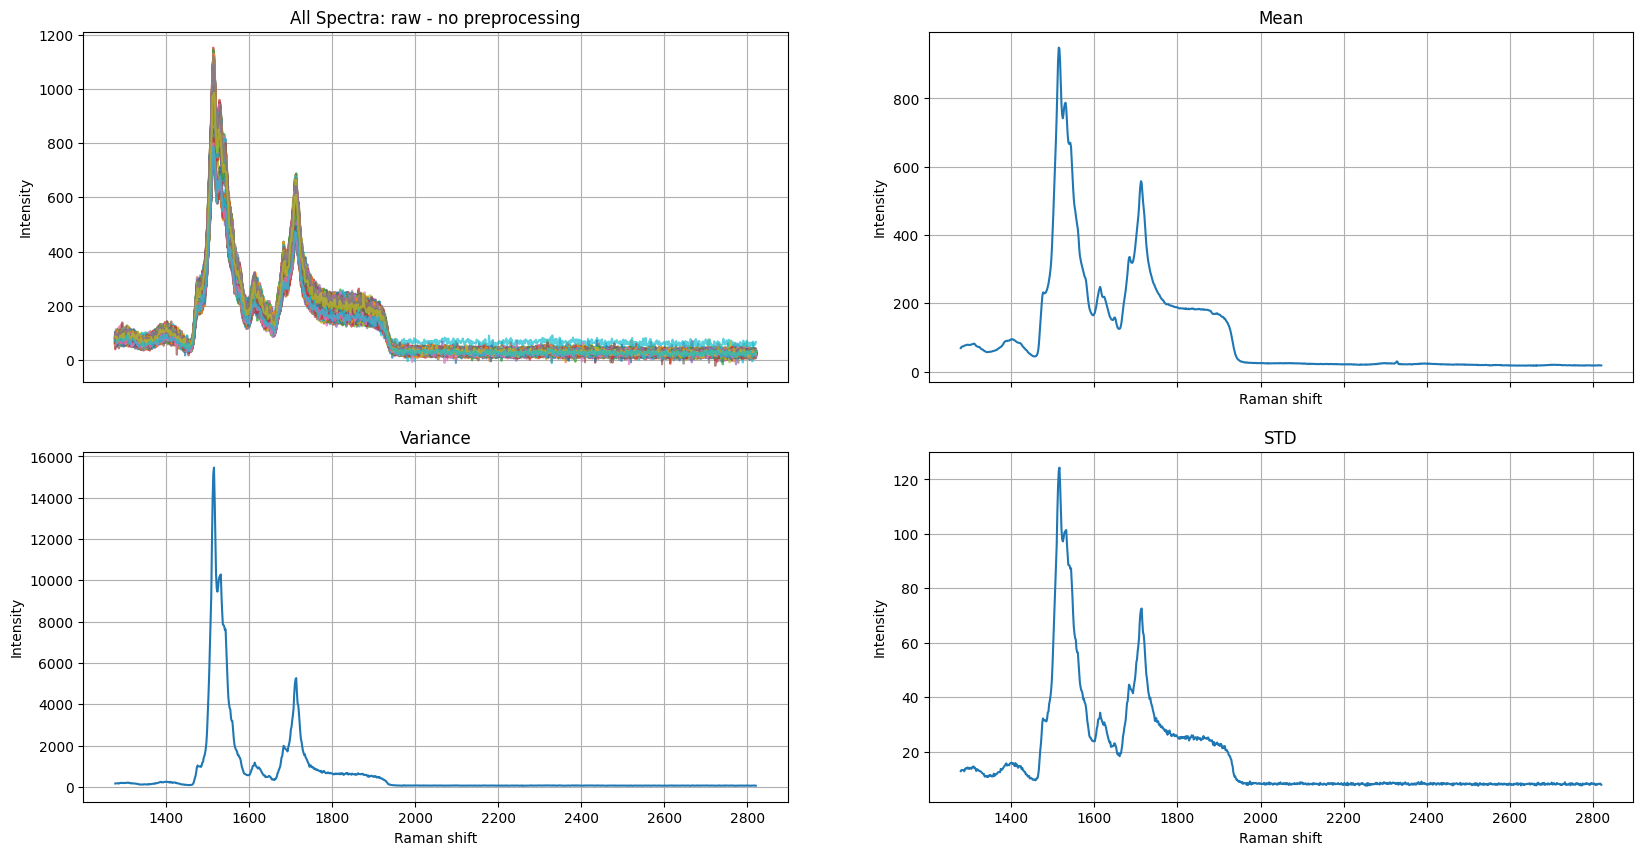

In [ ]:
# Stack the spatial dimensions ("X_0", "X_1", "X_2") into a single dimension called "spectra".
stacked_raw_ds = raw_ds_1.stack(spectra=("X_0", "X_1", "X_2"))

fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)
# Plot each spectrum as a line. Adjust the alpha for transparency if there are many lines.
for i in range(stacked_raw_ds.spectra.size):
    axes[0,0].plot(stacked_raw_ds["wave_number"], stacked_raw_ds.isel(spectra=i), alpha=0.7)

axes[0,0].set_xlabel('Raman shift')
axes[0,0].set_ylabel('Intensity')
axes[0,0].set_title('All Spectra: raw - no preprocessing')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].plot(raw_mean_values["wave_number"], raw_mean_values)
axes[0,1].set_xlabel('Raman shift')
axes[0,1].set_ylabel('Intensity')
axes[0,1].set_title('Mean')
axes[0,1].grid(visible=True, which='both', axis='both')

axes[1,0].plot(raw_variance_values["wave_number"], raw_variance_values)
axes[1,0].set_xlabel('Raman shift')
axes[1,0].set_ylabel('Intensity')
axes[1,0].set_title('Variance')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].plot(raw_std_values["wave_number"], raw_std_values)
axes[1,1].set_xlabel('Raman shift')
axes[1,1].set_ylabel('Intensity')
axes[1,1].set_title('STD')
axes[1,1].grid(visible=True, which='both', axis='both')

plt.show()

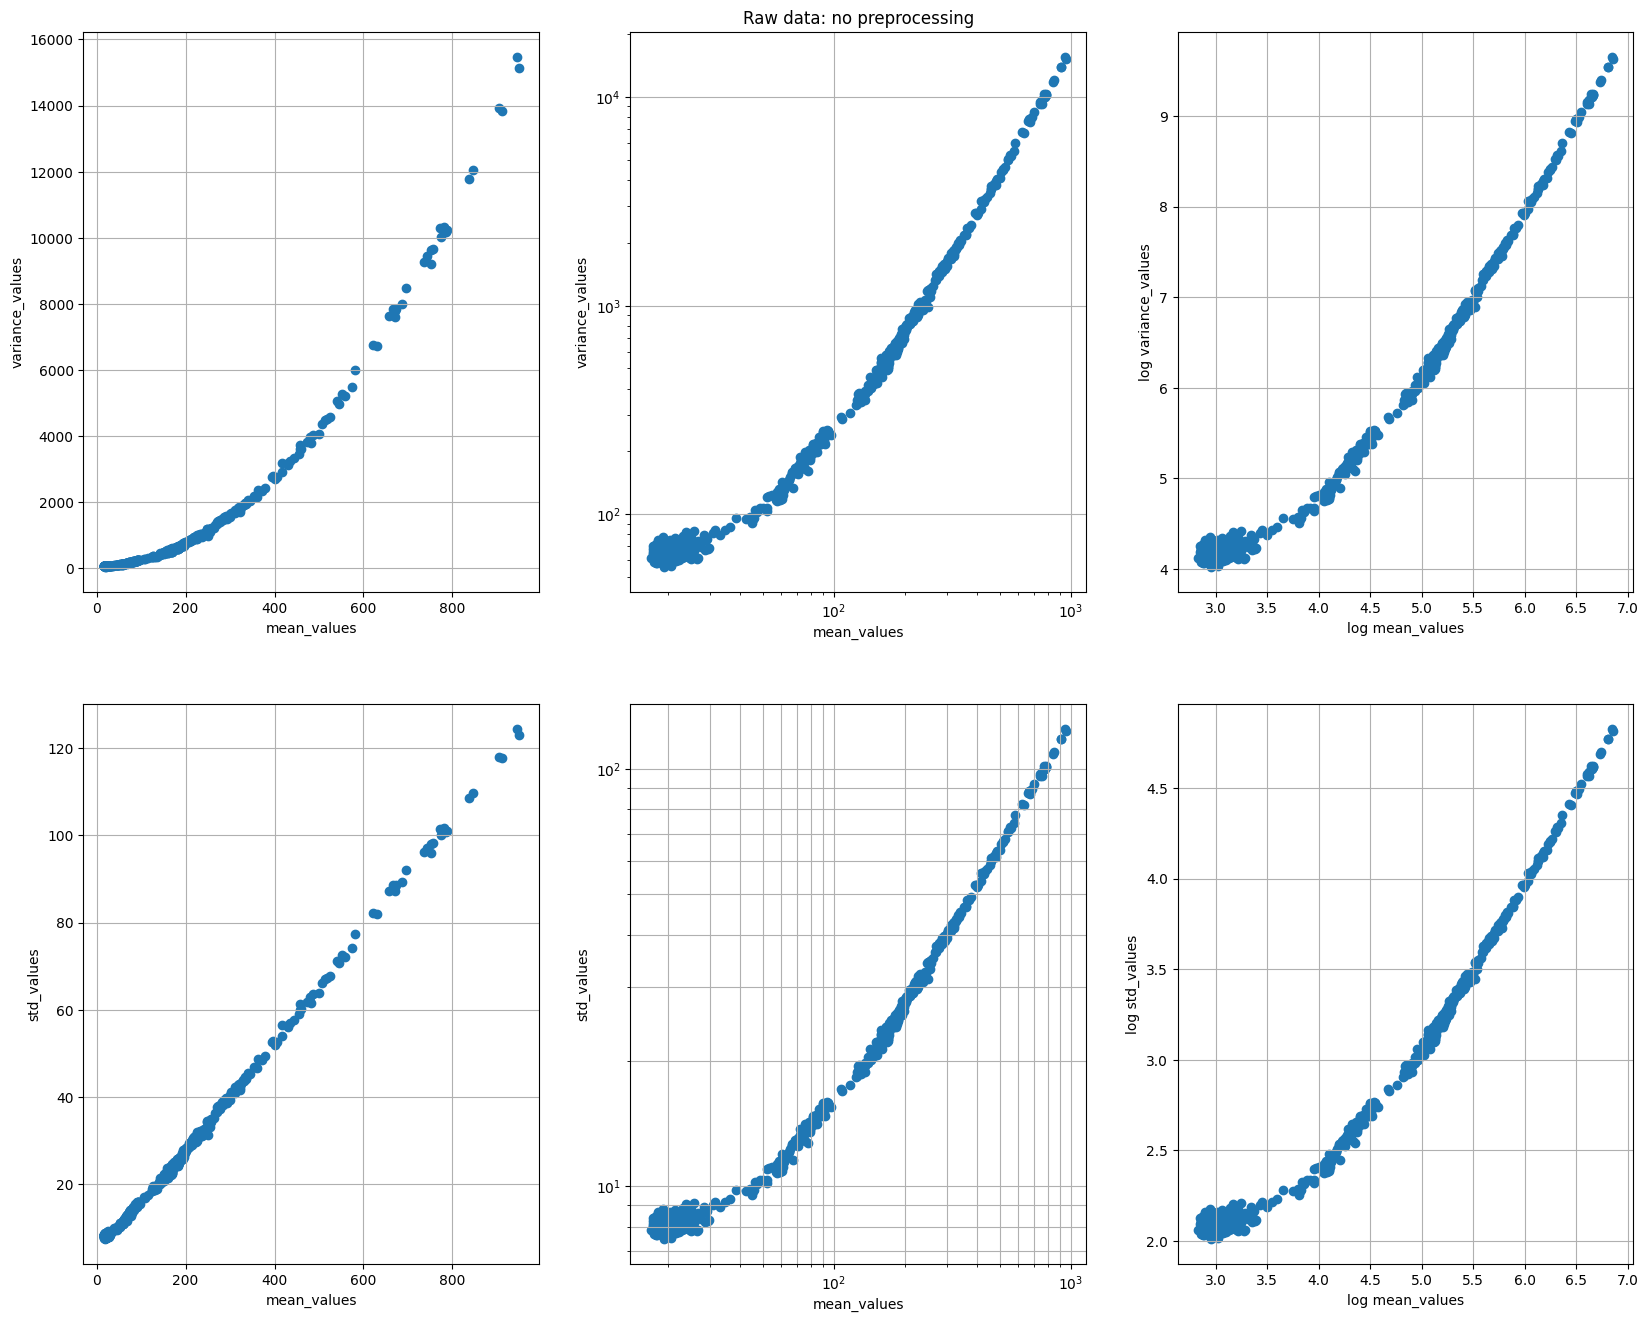

In [ ]:
fig = plt.figure(figsize=(20,16))
axes = fig.subplots(2, 3)

axes[0,0].scatter(x=raw_mean_values, y=raw_variance_values)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].grid(visible=True, which='major', axis='both')


axes[0,1].scatter(x=raw_mean_values, y=raw_variance_values)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('variance_values')
axes[0,1].set_title('Raw data: no preprocessing')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
axes[0,1].grid(visible=True, which='major', axis='both')

axes[0,2].scatter(x=np.log(raw_mean_values), y=np.log(raw_variance_values))
axes[0,2].set_xlabel('log mean_values')
axes[0,2].set_ylabel('log variance_values')
axes[0,2].grid(visible=True, which='both', axis='both')

axes[1,0].scatter(x=raw_mean_values, y=raw_std_values)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('std_values')
axes[1,0].grid(visible=True, which='major', axis='both')

axes[1,1].scatter(x=raw_mean_values, y=raw_std_values)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('std_values')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
axes[1,1].grid(visible=True, which='both', axis='both')

axes[1,2].scatter(x=np.log(raw_mean_values), y=np.log(raw_std_values))
axes[1,2].set_xlabel('log mean_values')
axes[1,2].set_ylabel('log std_values')
axes[1,2].grid(visible=True, which='both', axis='both')

plt.show()

In [ ]:
# Choosing a linear part
linear_raw_mean_values = raw_mean_values[raw_mean_values>1e2]
linear_raw_variance_values = raw_variance_values[raw_mean_values>1e2]
linear_raw_std_values = raw_std_values[raw_mean_values>1e2]

# Fitting with 1-order polynom
raw_variance_vs_mean_fit = np.polyfit(
    linear_raw_mean_values,
    linear_raw_variance_values,
    1
)
raw_std_vs_mean_fit = np.polyfit(
    linear_raw_mean_values,
    linear_raw_std_values,
    1
)
# Results: [slope, intersect]
print('Raw dataset')
print(f"Variance as a function of mean: {raw_variance_vs_mean_fit}")
print(f"STD as a function of mean: {raw_std_vs_mean_fit}")

############################################################## LOG part ##############################################################
# Choosing a linear part
log_raw_mean_values = np.log(raw_mean_values)
log_raw_variance_values = np.log(raw_variance_values)
log_raw_std_values = np.log(raw_std_values)

linear_log_raw_mean_values = log_raw_mean_values[log_raw_mean_values>5]
linear_log_raw_variance_values = log_raw_variance_values[log_raw_mean_values>5]
linear_log_raw_std_values = log_raw_std_values[log_raw_mean_values>5]

# Fitting with 1-order polynom
log_variance_vs_mean_fit = np.polyfit(
    linear_log_raw_mean_values,
    linear_log_raw_variance_values,
    1
)
log_std_vs_mean_fit = np.polyfit(
    linear_log_raw_mean_values,
    linear_log_raw_std_values,
    1
)
# Results: [slope, intersect]
print('log(Raw dataset)')
print(f"Variance as a function of mean: {log_variance_vs_mean_fit}")
print(f"STD as a function of mean: {log_std_vs_mean_fit}")

Raw dataset
Variance as a function of mean: [   15.17221611 -2334.66038322]
STD as a function of mean: [0.1273536  1.96481958]
log(Raw dataset)
Variance as a function of mean: [ 1.90498865 -3.46976023]
STD as a function of mean: [ 0.95249432 -1.73488011]


In [ ]:
raw_ds_1.isnan()


NameError: name 'raw_ds_1' is not defined